In [1]:
import warnings, logging
warnings.filterwarnings("ignore")
logging.getLogger("prophet").setLevel(logging.ERROR)
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)
 
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
 
# ── Time-Series ───────────────────────────────────────────────────────────
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
from statsmodels.tsa.seasonal import STL
from statsmodels.stats.multicomp import pairwise_tukeyhsd
 
# ── ML ────────────────────────────────────────────────────────────────────
import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import (Ridge, Lasso, ElasticNet,
                                   BayesianRidge, QuantileRegressor)
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               ExtraTreesRegressor, StackingRegressor)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance

In [2]:
REGION_COLORS = {
    "New England":     "#1E40AF",
    "Mideast":         "#7C3AED",
    "Great Lakes":     "#059669",
    "Plains":          "#D97706",
    "Southeast":       "#DC2626",
    "Southwest":       "#DB2777",
    "Rocky Mountain":  "#0891B2",
    "Far West":        "#65A30D",
}
ACCENT, HIGHLIGHT, GREEN, AMBER, PURPLE, NEUTRAL = "#2563EB","#DC2626","#16A34A","#D97706","#7C3AED","#64748B"
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({"figure.dpi":150, "savefig.bbox":"tight",
                     "savefig.facecolor":"white"})

In [3]:
raw = pd.read_csv("GDPDollarsRegions.csv", header=None)
raw.columns = ["GeoFIPS","Region","LineCode","Description"] + \
              [f"{yr}:Q{q}" for yr in range(2022,2026) for q in range(1,5)]
raw["Description"] = raw["Description"].str.strip()
Q_COLS = [c for c in raw.columns if ":" in c]


In [4]:
long = raw.melt(id_vars=["GeoFIPS","Region","LineCode","Description"],
                value_vars=Q_COLS, var_name="Quarter", value_name="GDP_M")
long["Period"]  = long["Quarter"].apply(
    lambda s: pd.Period(f"{s.split(':')[0]}Q{s.split(':')[1][1]}"))
long["Year"]    = long["Period"].apply(lambda p: p.year)
long["Qtr"]     = long["Period"].apply(lambda p: p.quarter)
long["GDP_B"]   = long["GDP_M"] / 1_000
long["GDP_T"]   = long["GDP_M"] / 1_000_000
long = long.sort_values(["Region","Description","Period"])

In [5]:
us_total_by_q = (long[long["Description"]=="All industry total"]
                 .groupby("Quarter")["GDP_M"].sum().reset_index())
us_total_by_q["Period"] = us_total_by_q["Quarter"].apply(
    lambda s: pd.Period(f"{s.split(':')[0]}Q{s.split(':')[1][1]}"))
us_total_by_q = us_total_by_q.sort_values("Period")
us_gdp = us_total_by_q["GDP_M"].values.astype(float)

In [6]:
# Region-level All-industry totals
reg_total = long[long["Description"]=="All industry total"].copy()
reg_total["QoQ_Growth"] = (
    reg_total.sort_values("Period")
             .groupby("Region")["GDP_M"].pct_change() * 100)
reg_total["YoY_Growth"] = (
    reg_total.sort_values("Period")
             .groupby("Region")["GDP_M"].pct_change(4) * 100)

In [7]:
# Industry breakdown (non-aggregate)
EXCL = {"All industry total","Private industries",
        "Government and government enterprises",
        "Durable goods manufacturing","Nondurable goods manufacturing",
        "Federal civilian","Military","State and local"}
ind_detail = long[~long["Description"].isin(EXCL)].copy()

In [8]:
latest_q  = Q_COLS[-1]
REGIONS   = raw["Region"].unique().tolist()
N_REGIONS = len(REGIONS)
 
print(f"Regions ({N_REGIONS}): {REGIONS}")
print(f"Quarters: {Q_COLS}")
print(f"Long-format rows: {len(long):,}")
print(f"US GDP range: ${us_gdp.min()/1e6:.2f}T – ${us_gdp.max()/1e6:.2f}T")

Regions (8): ['New England', 'Mideast', 'Great Lakes', 'Plains', 'Southeast', 'Southwest', 'Rocky Mountain', 'Far West']
Quarters: ['2022:Q1', '2022:Q2', '2022:Q3', '2022:Q4', '2023:Q1', '2023:Q2', '2023:Q3', '2023:Q4', '2024:Q1', '2024:Q2', '2024:Q3', '2024:Q4', '2025:Q1', '2025:Q2', '2025:Q3', '2025:Q4']
Long-format rows: 3,456
US GDP range: $25.11T – $31.25T


In [9]:
#Regional Pivot for ML Models
reg_pivot = reg_total.pivot_table(index="Region", columns="Quarter", values="GDP_M")
reg_pivot = reg_pivot.reindex(columns=Q_COLS)
X_all  = reg_pivot[Q_COLS[:-1]].values
y_all  = reg_pivot[Q_COLS[-1]].values
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X_all)
tscv   = TimeSeriesSplit(n_splits=3)

In [11]:
%matplotlib inline

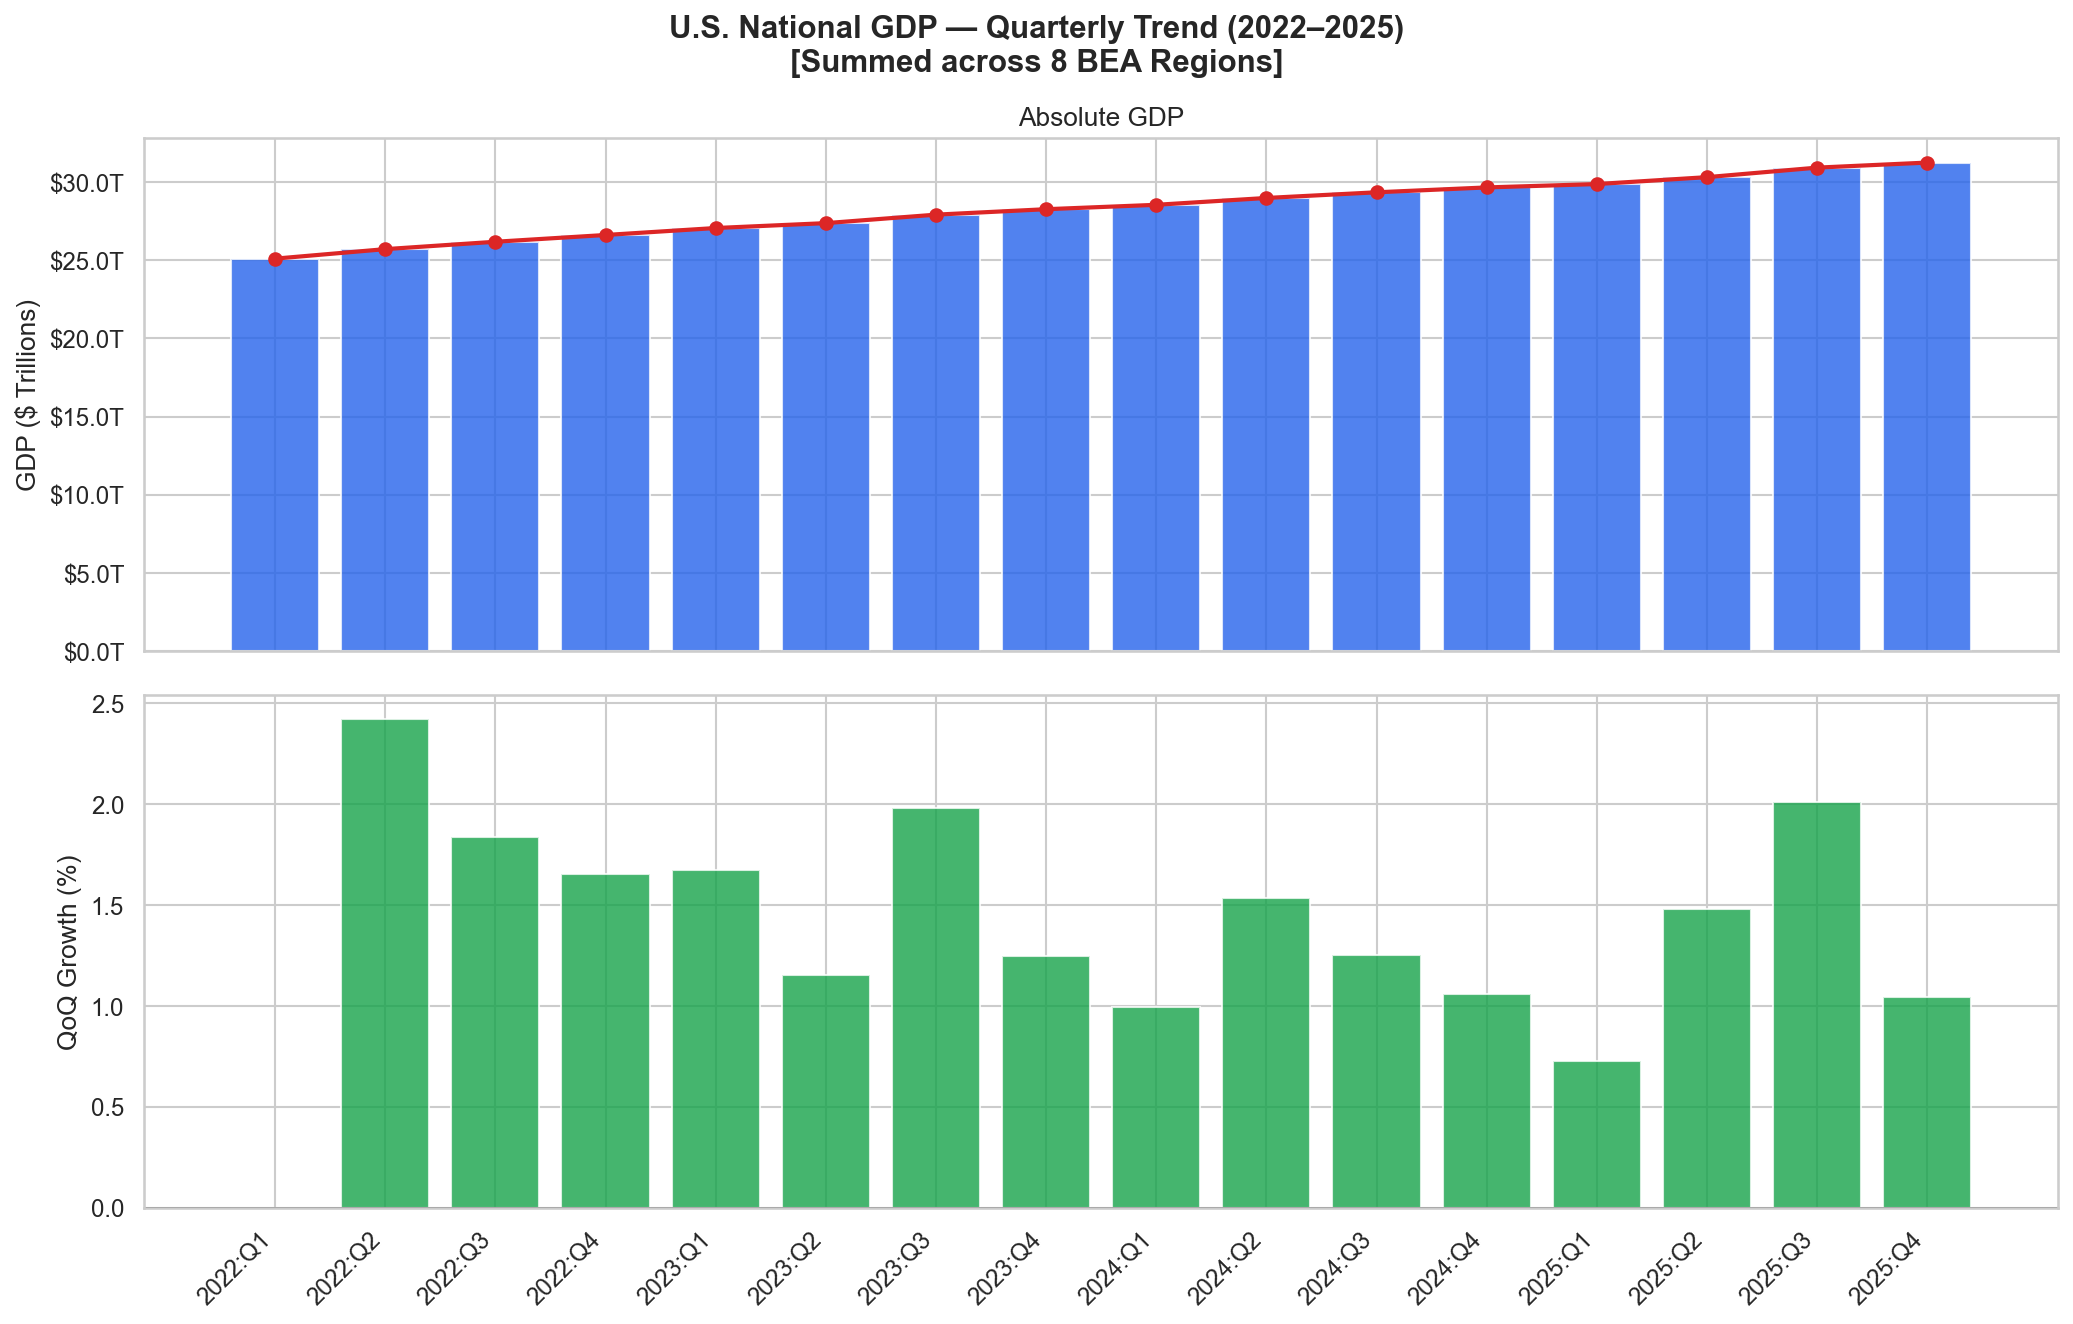

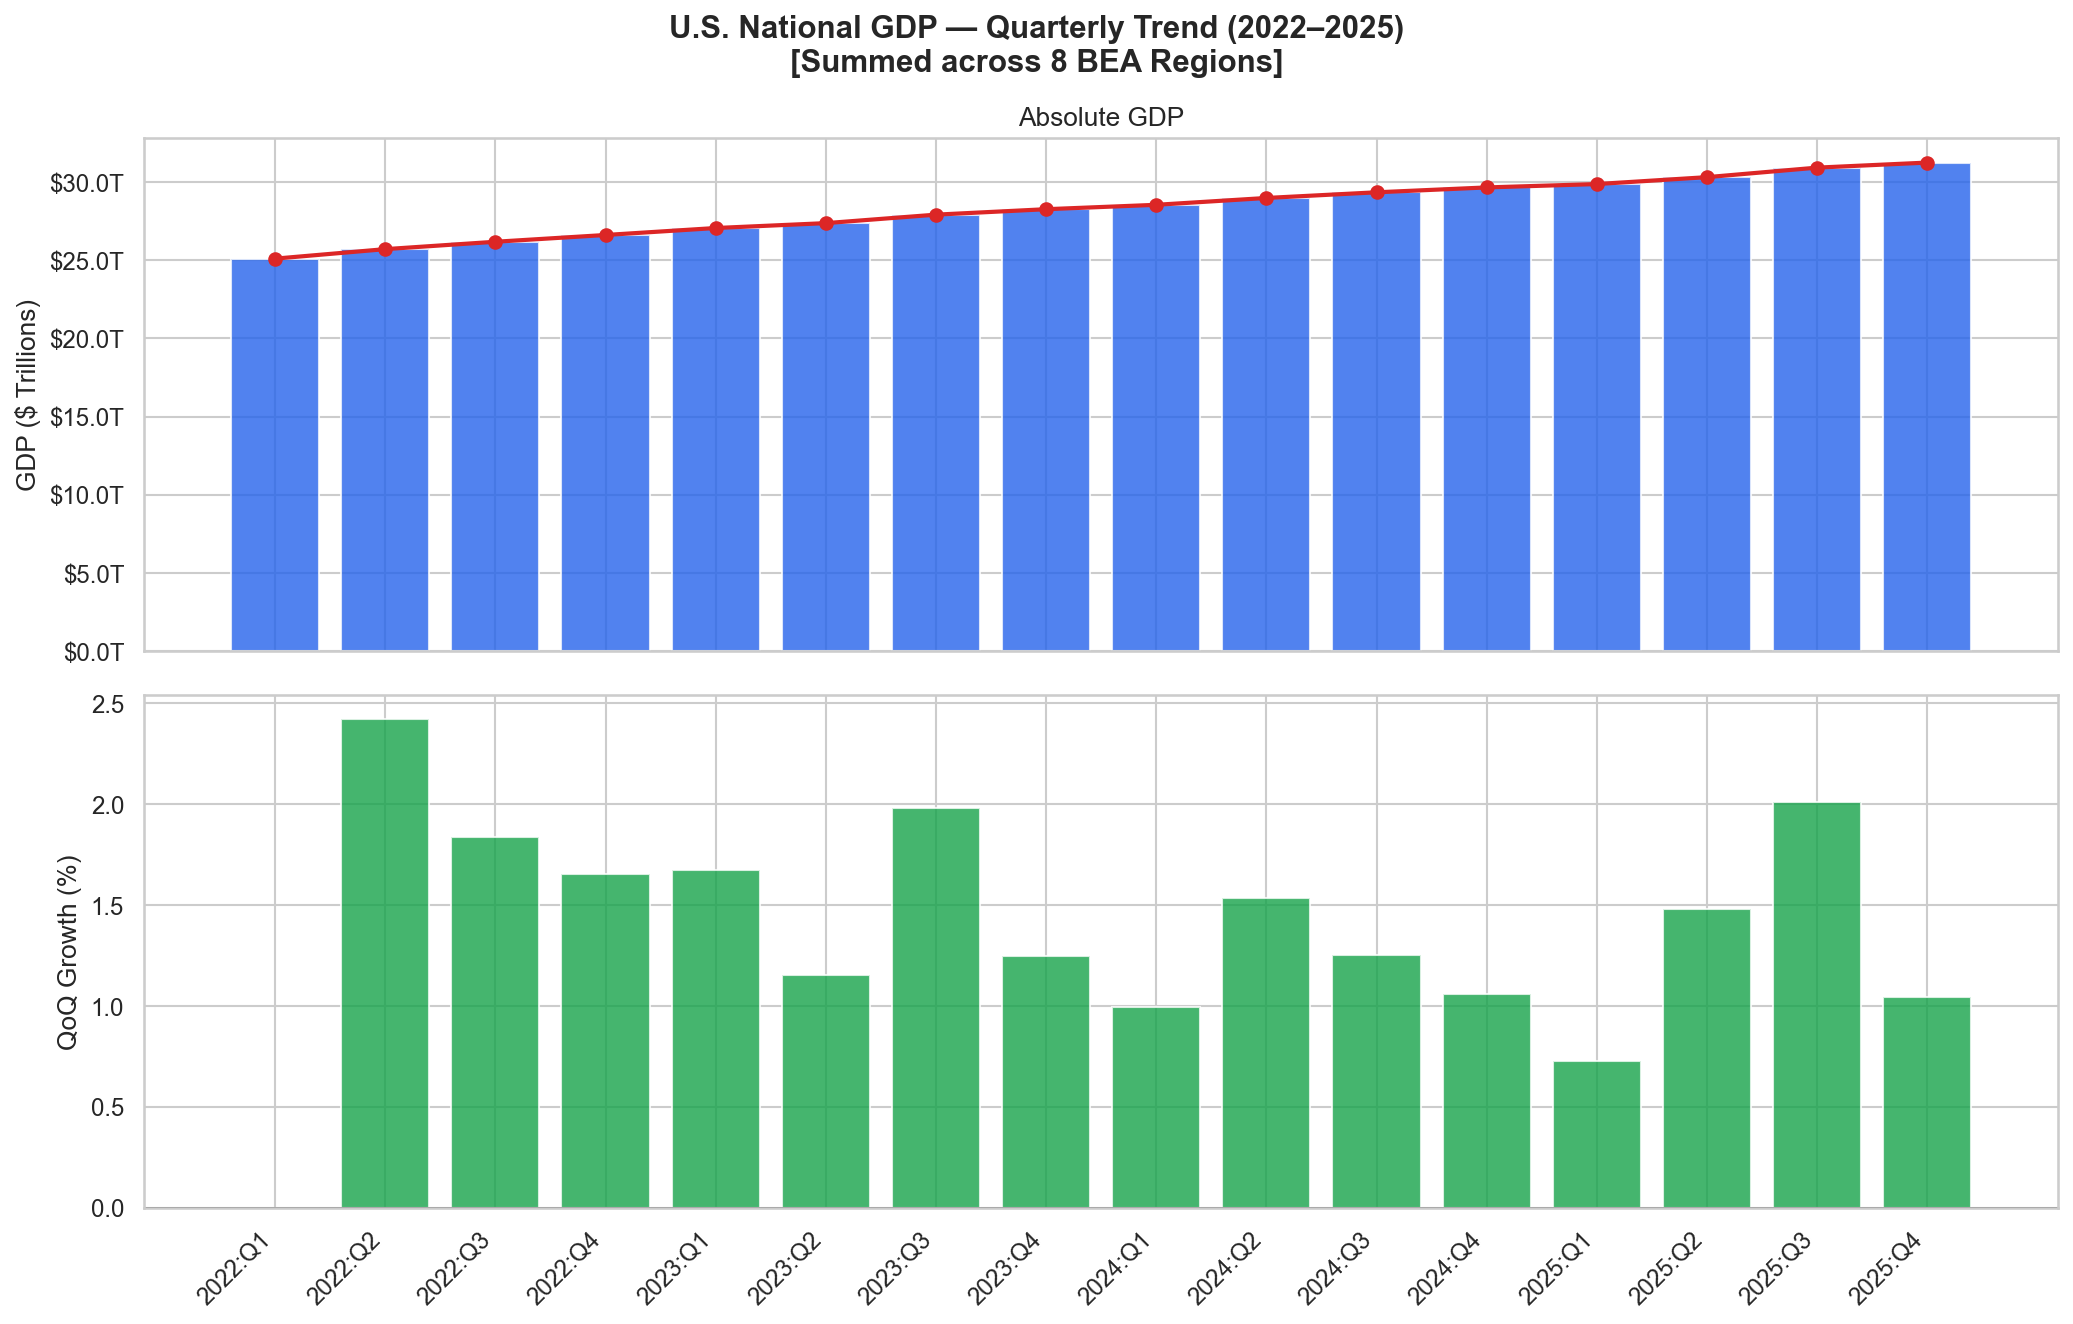

In [12]:
# ── 1-A  US Total GDP Trend ───────────────────────────────────────────────
fig, axes = plt.subplots(2,1,figsize=(14,9), sharex=True)
fig.suptitle("U.S. National GDP — Quarterly Trend (2022–2025)\n"
             "[Summed across 8 BEA Regions]", fontsize=15, fontweight="bold")
xs = list(range(len(Q_COLS)))
gdp_t = us_gdp / 1e6
axes[0].bar(xs, gdp_t, color=ACCENT, alpha=0.8)
axes[0].plot(xs, gdp_t, color=HIGHLIGHT, marker="o", lw=2)
axes[0].set_ylabel("GDP ($ Trillions)")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"${x:.1f}T"))
axes[0].set_title("Absolute GDP")
qoq = pd.Series(gdp_t).pct_change()*100
cols_bar = [GREEN if v>=0 else HIGHLIGHT for v in qoq.fillna(0)]
axes[1].bar(xs, qoq.fillna(0), color=cols_bar, alpha=0.8)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_ylabel("QoQ Growth (%)")
axes[1].set_xticks(xs); axes[1].set_xticklabels(Q_COLS, rotation=45, ha="right")
plt.tight_layout()
plt.show()

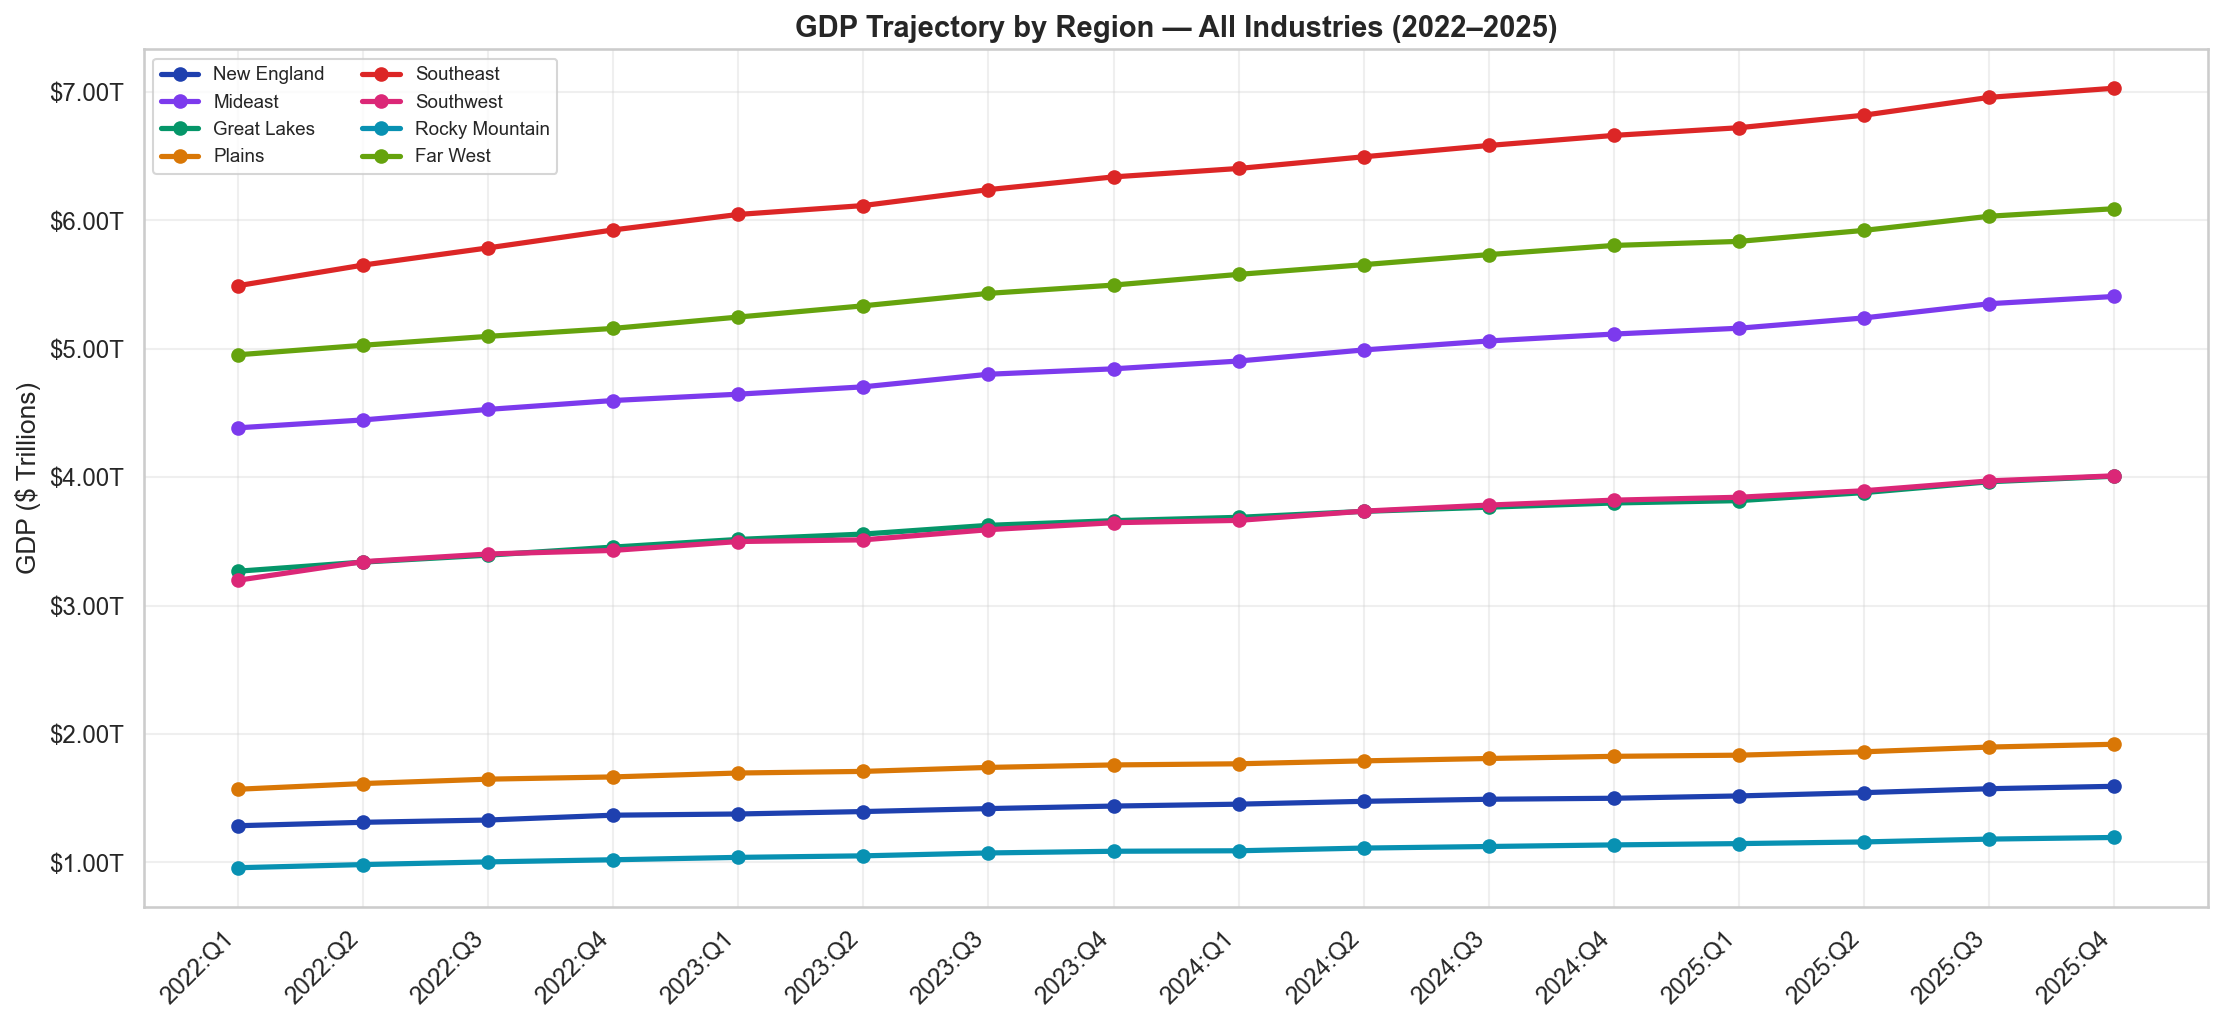

In [13]:
fig, ax = plt.subplots(figsize=(15,7))
for reg in REGIONS:
    rdf = reg_total[reg_total["Region"]==reg].sort_values("Period")
    ax.plot(range(len(Q_COLS)), rdf["GDP_T"].values, marker="o", lw=2.5,
            color=REGION_COLORS[reg], label=reg)
ax.set_xticks(range(len(Q_COLS)))
ax.set_xticklabels(Q_COLS, rotation=45, ha="right")
ax.set_ylabel("GDP ($ Trillions)"); ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x,_: f"${x:.2f}T"))
ax.set_title("GDP Trajectory by Region — All Industries (2022–2025)",
             fontsize=14, fontweight="bold")
ax.legend(loc="upper left", fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

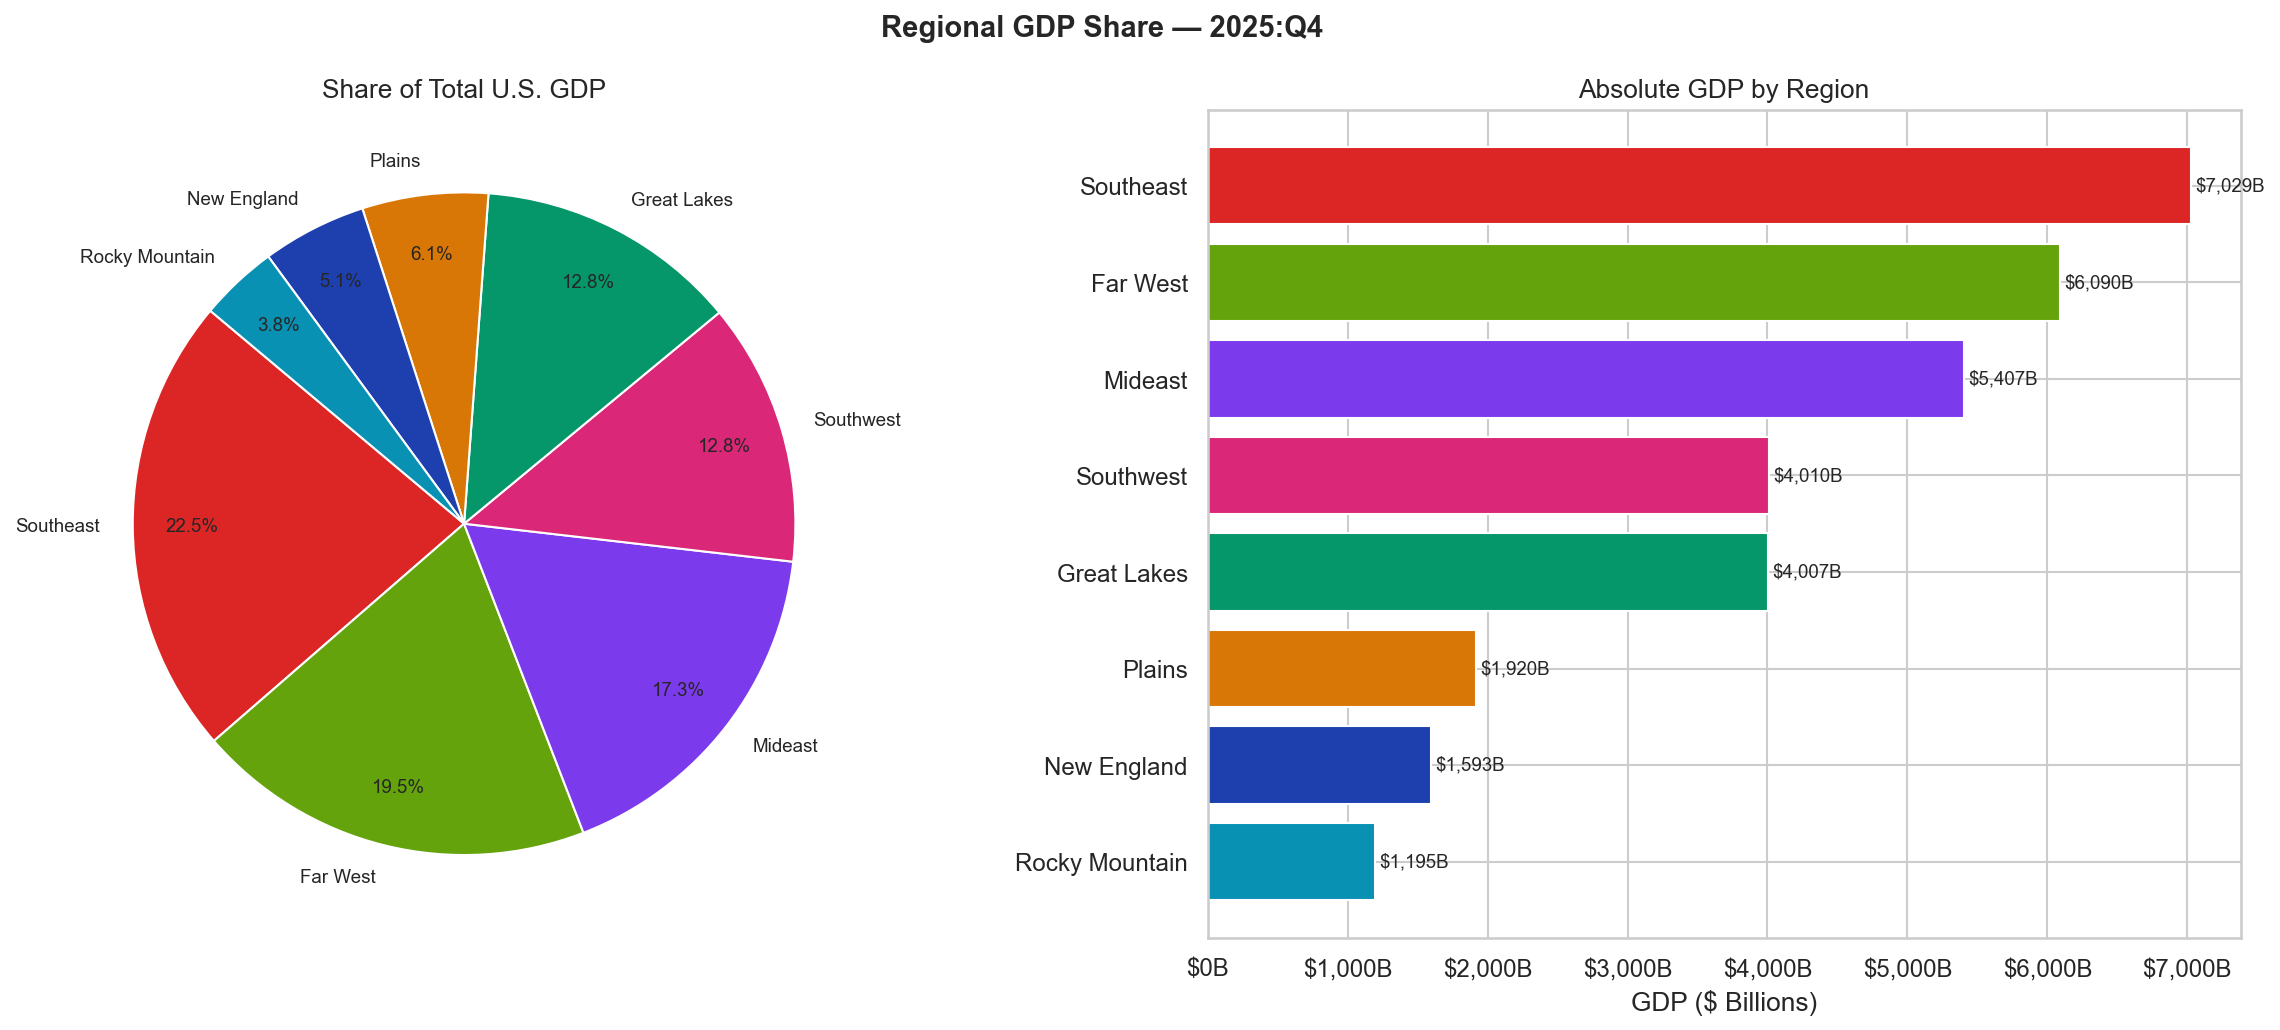

In [14]:
# ── Region Share of US GDP (Latest Quarter) ──────────────────────────
latest_shares = reg_total[reg_total["Quarter"]==latest_q].sort_values("GDP_M", ascending=False)
colors_pie = [REGION_COLORS[r] for r in latest_shares["Region"]]
 
fig, axes = plt.subplots(1,2,figsize=(16,7))
fig.suptitle(f"Regional GDP Share — {latest_q}", fontsize=14, fontweight="bold")
wedges, texts, autotexts = axes[0].pie(
    latest_shares["GDP_B"], labels=latest_shares["Region"],
    autopct="%1.1f%%", colors=colors_pie, startangle=140,
    textprops={"fontsize":9}, pctdistance=0.82)
[a.set_fontsize(9) for a in autotexts]
axes[0].set_title("Share of Total U.S. GDP")
 
bars = axes[1].barh(latest_shares["Region"][::-1], latest_shares["GDP_B"][::-1],
                    color=[REGION_COLORS[r] for r in latest_shares["Region"][::-1]])
for bar,val in zip(bars, latest_shares["GDP_B"][::-1]):
    axes[1].text(bar.get_width()+30, bar.get_y()+bar.get_height()/2,
                 f"${val:,.0f}B", va="center", fontsize=9)
axes[1].set_xlabel("GDP ($ Billions)")
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"${x:,.0f}B"))
axes[1].set_title("Absolute GDP by Region")
plt.tight_layout()
plt.show()

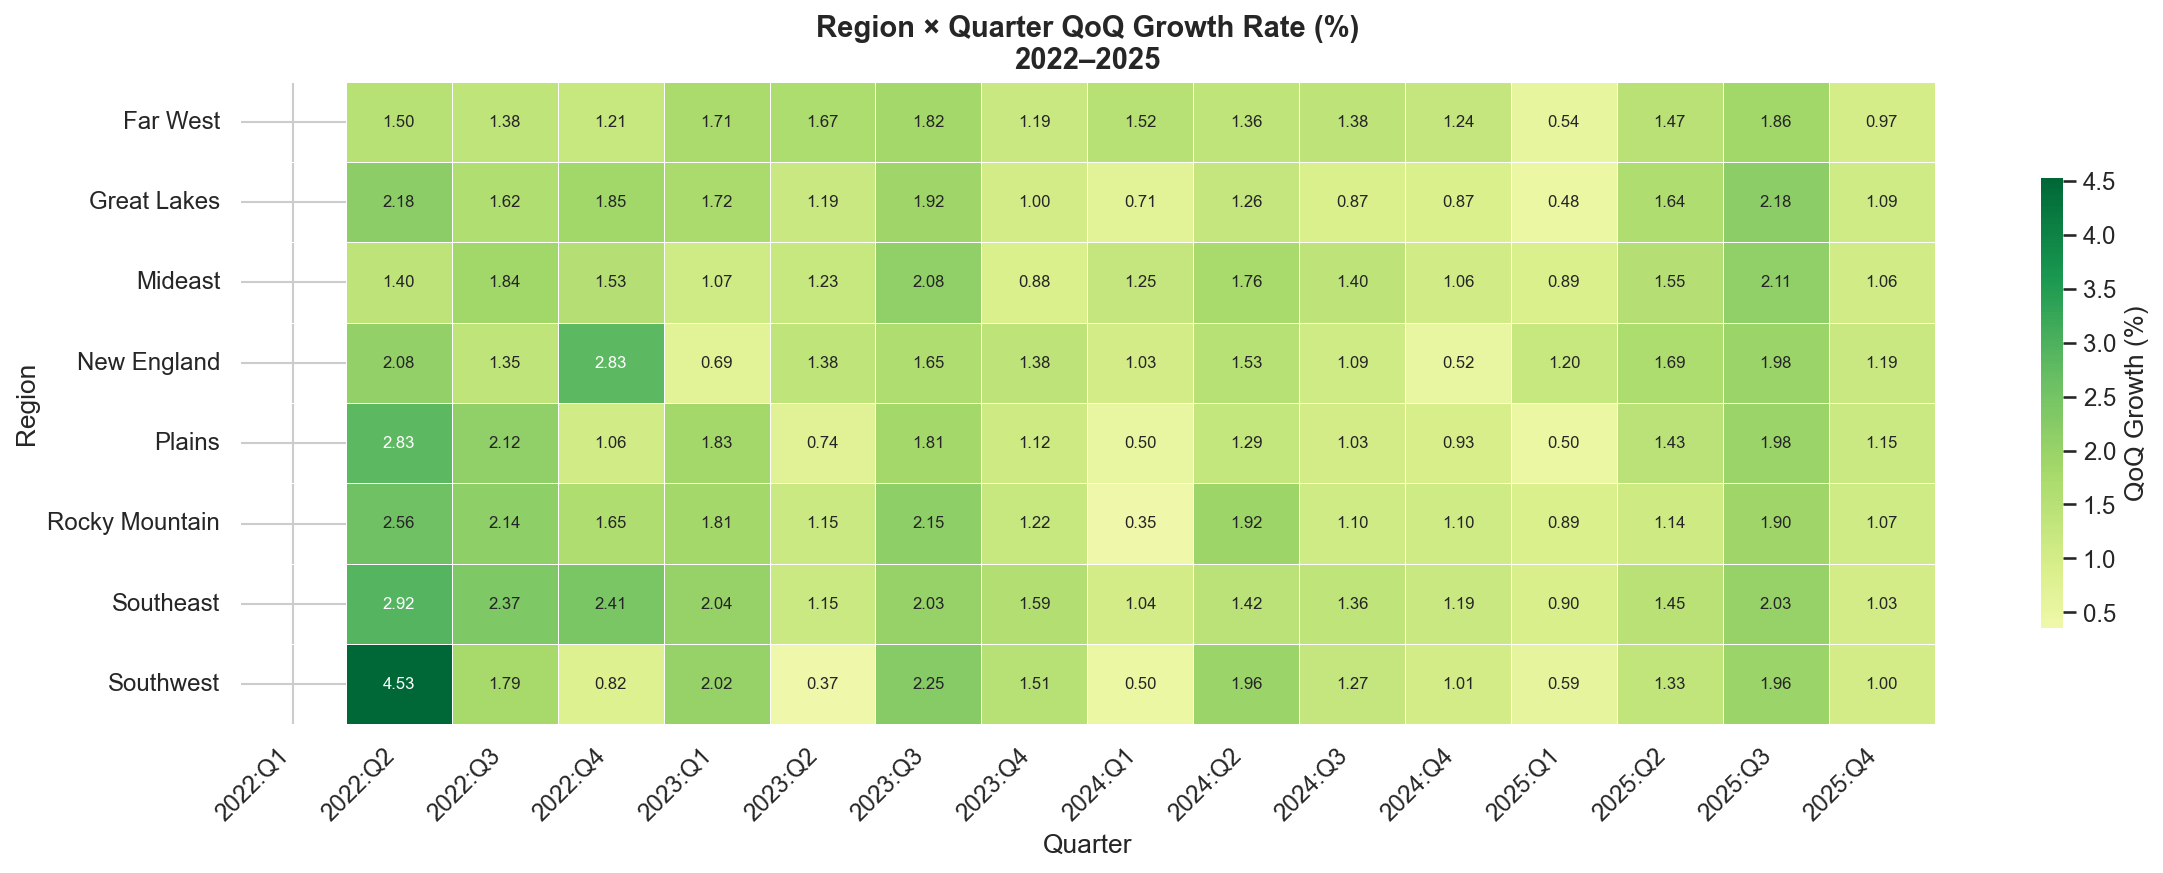

In [15]:
# QoQ Growth Heatmap (Regions × Quarters) ─────────────────────────
qoq_pivot = reg_total.pivot_table(index="Region", columns="Quarter", values="QoQ_Growth")
qoq_pivot = qoq_pivot.reindex(columns=Q_COLS)
 
fig, ax = plt.subplots(figsize=(16,6))
sns.heatmap(qoq_pivot, ax=ax, cmap="RdYlGn", center=0,
            annot=True, fmt=".2f", annot_kws={"size":8},
            linewidths=0.4, linecolor="white",
            cbar_kws={"label":"QoQ Growth (%)", "shrink":0.7})
ax.set_title("Region × Quarter QoQ Growth Rate (%)\n2022–2025",
             fontsize=14, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

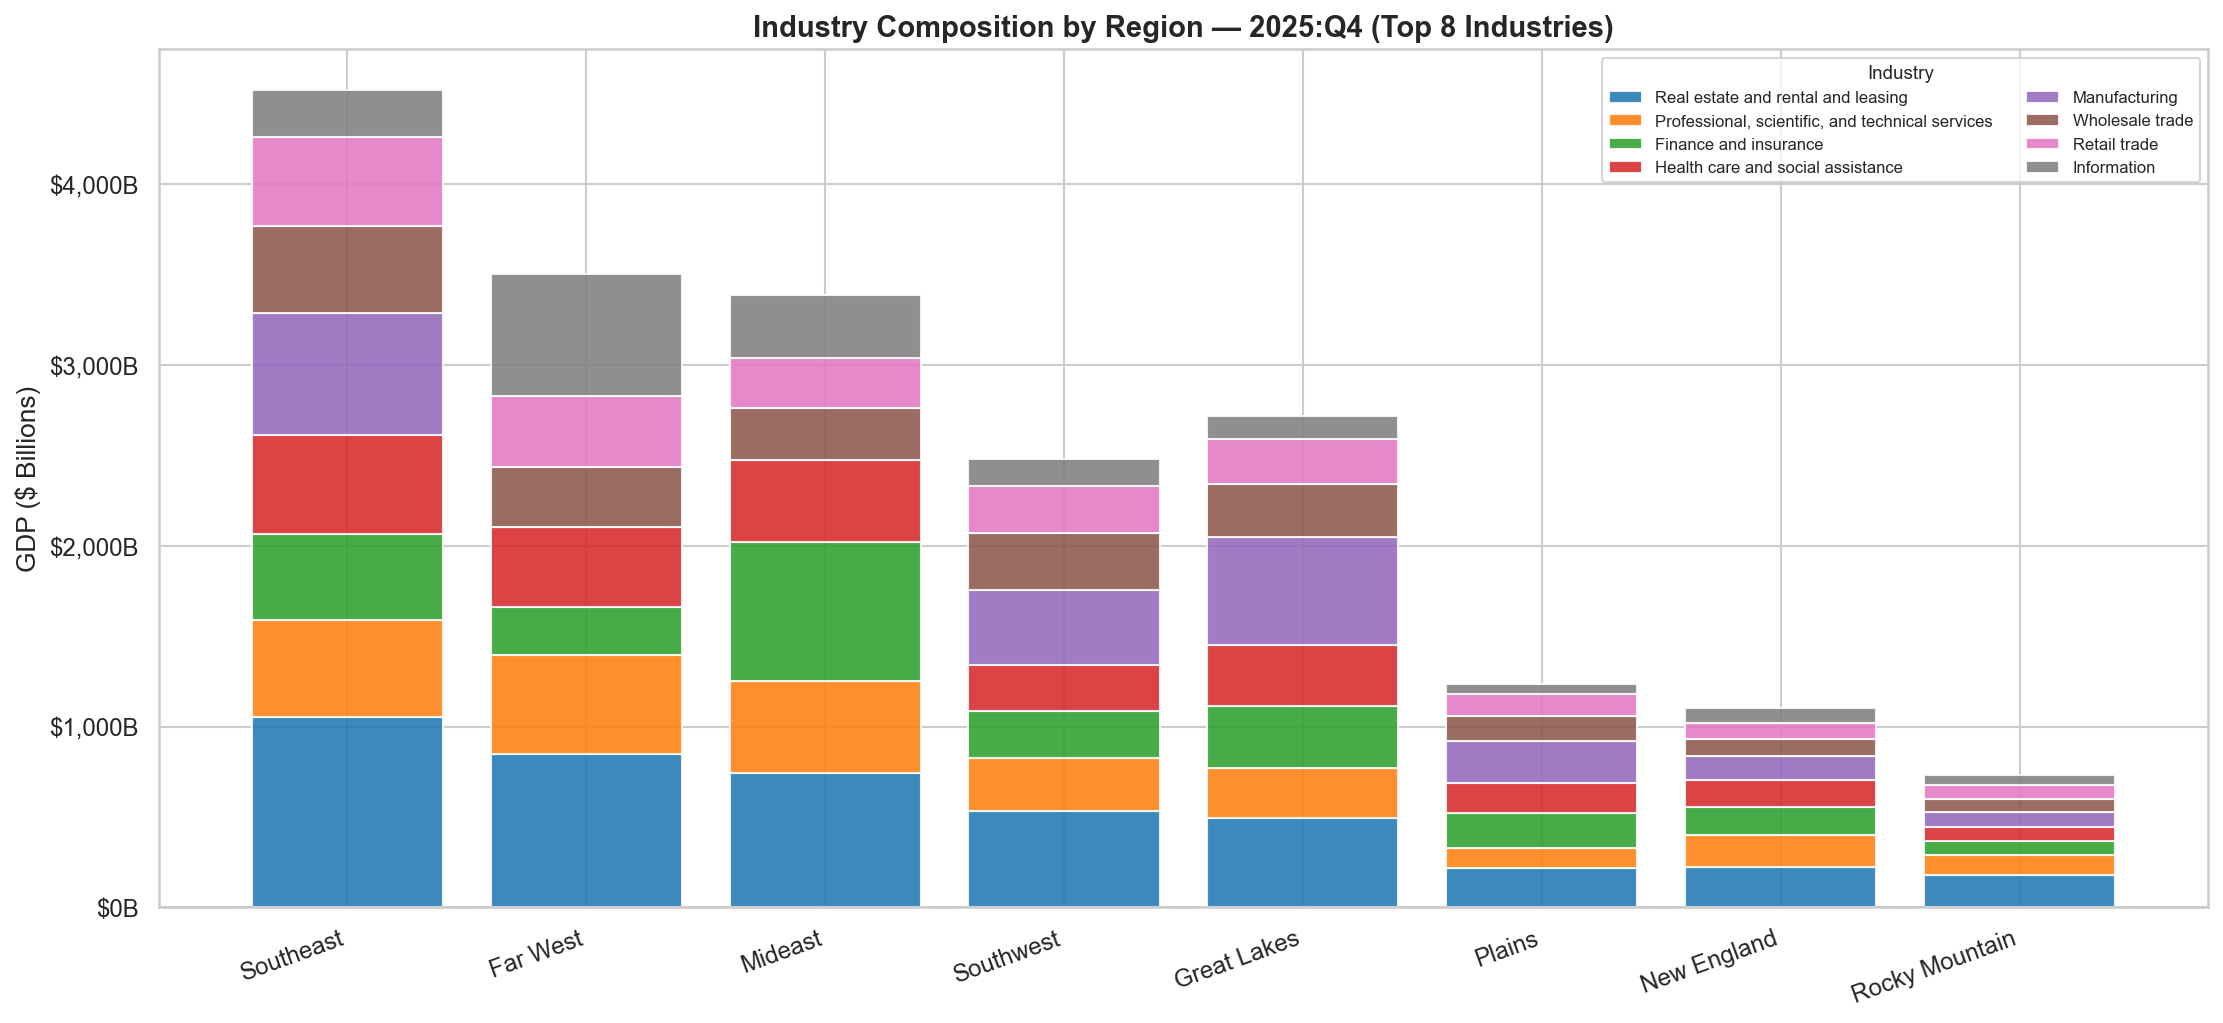

In [16]:
# ── Industry Breakdown by Region (Latest Quarter, Stacked Bar) ───────
ind_latest = ind_detail[ind_detail["Quarter"]==latest_q].copy()
ind_pivot_r = ind_latest.pivot_table(index="Region", columns="Description",
                                      values="GDP_B", aggfunc="sum").fillna(0)
top_inds = ind_pivot_r.sum(axis=0).nlargest(8).index.tolist()
ind_pivot_top = ind_pivot_r[top_inds]
region_order = latest_shares["Region"].tolist()
ind_pivot_top = ind_pivot_top.reindex(region_order)
 
fig, ax = plt.subplots(figsize=(15,7))
colors_ind = plt.cm.tab10.colors[:8]
bottom = np.zeros(N_REGIONS)
for i, col in enumerate(top_inds):
    vals = ind_pivot_top[col].values
    bars = ax.bar(range(N_REGIONS), vals, bottom=bottom,
                  color=colors_ind[i], label=col.strip(), alpha=0.87)
    bottom += vals
ax.set_xticks(range(N_REGIONS))
ax.set_xticklabels(region_order, rotation=20, ha="right")
ax.set_ylabel("GDP ($ Billions)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"${x:,.0f}B"))
ax.set_title(f"Industry Composition by Region — {latest_q} (Top 8 Industries)",
             fontsize=14, fontweight="bold")
ax.legend(loc="upper right", fontsize=8, ncol=2,
          title="Industry", title_fontsize=9)
plt.tight_layout()
plt.show()

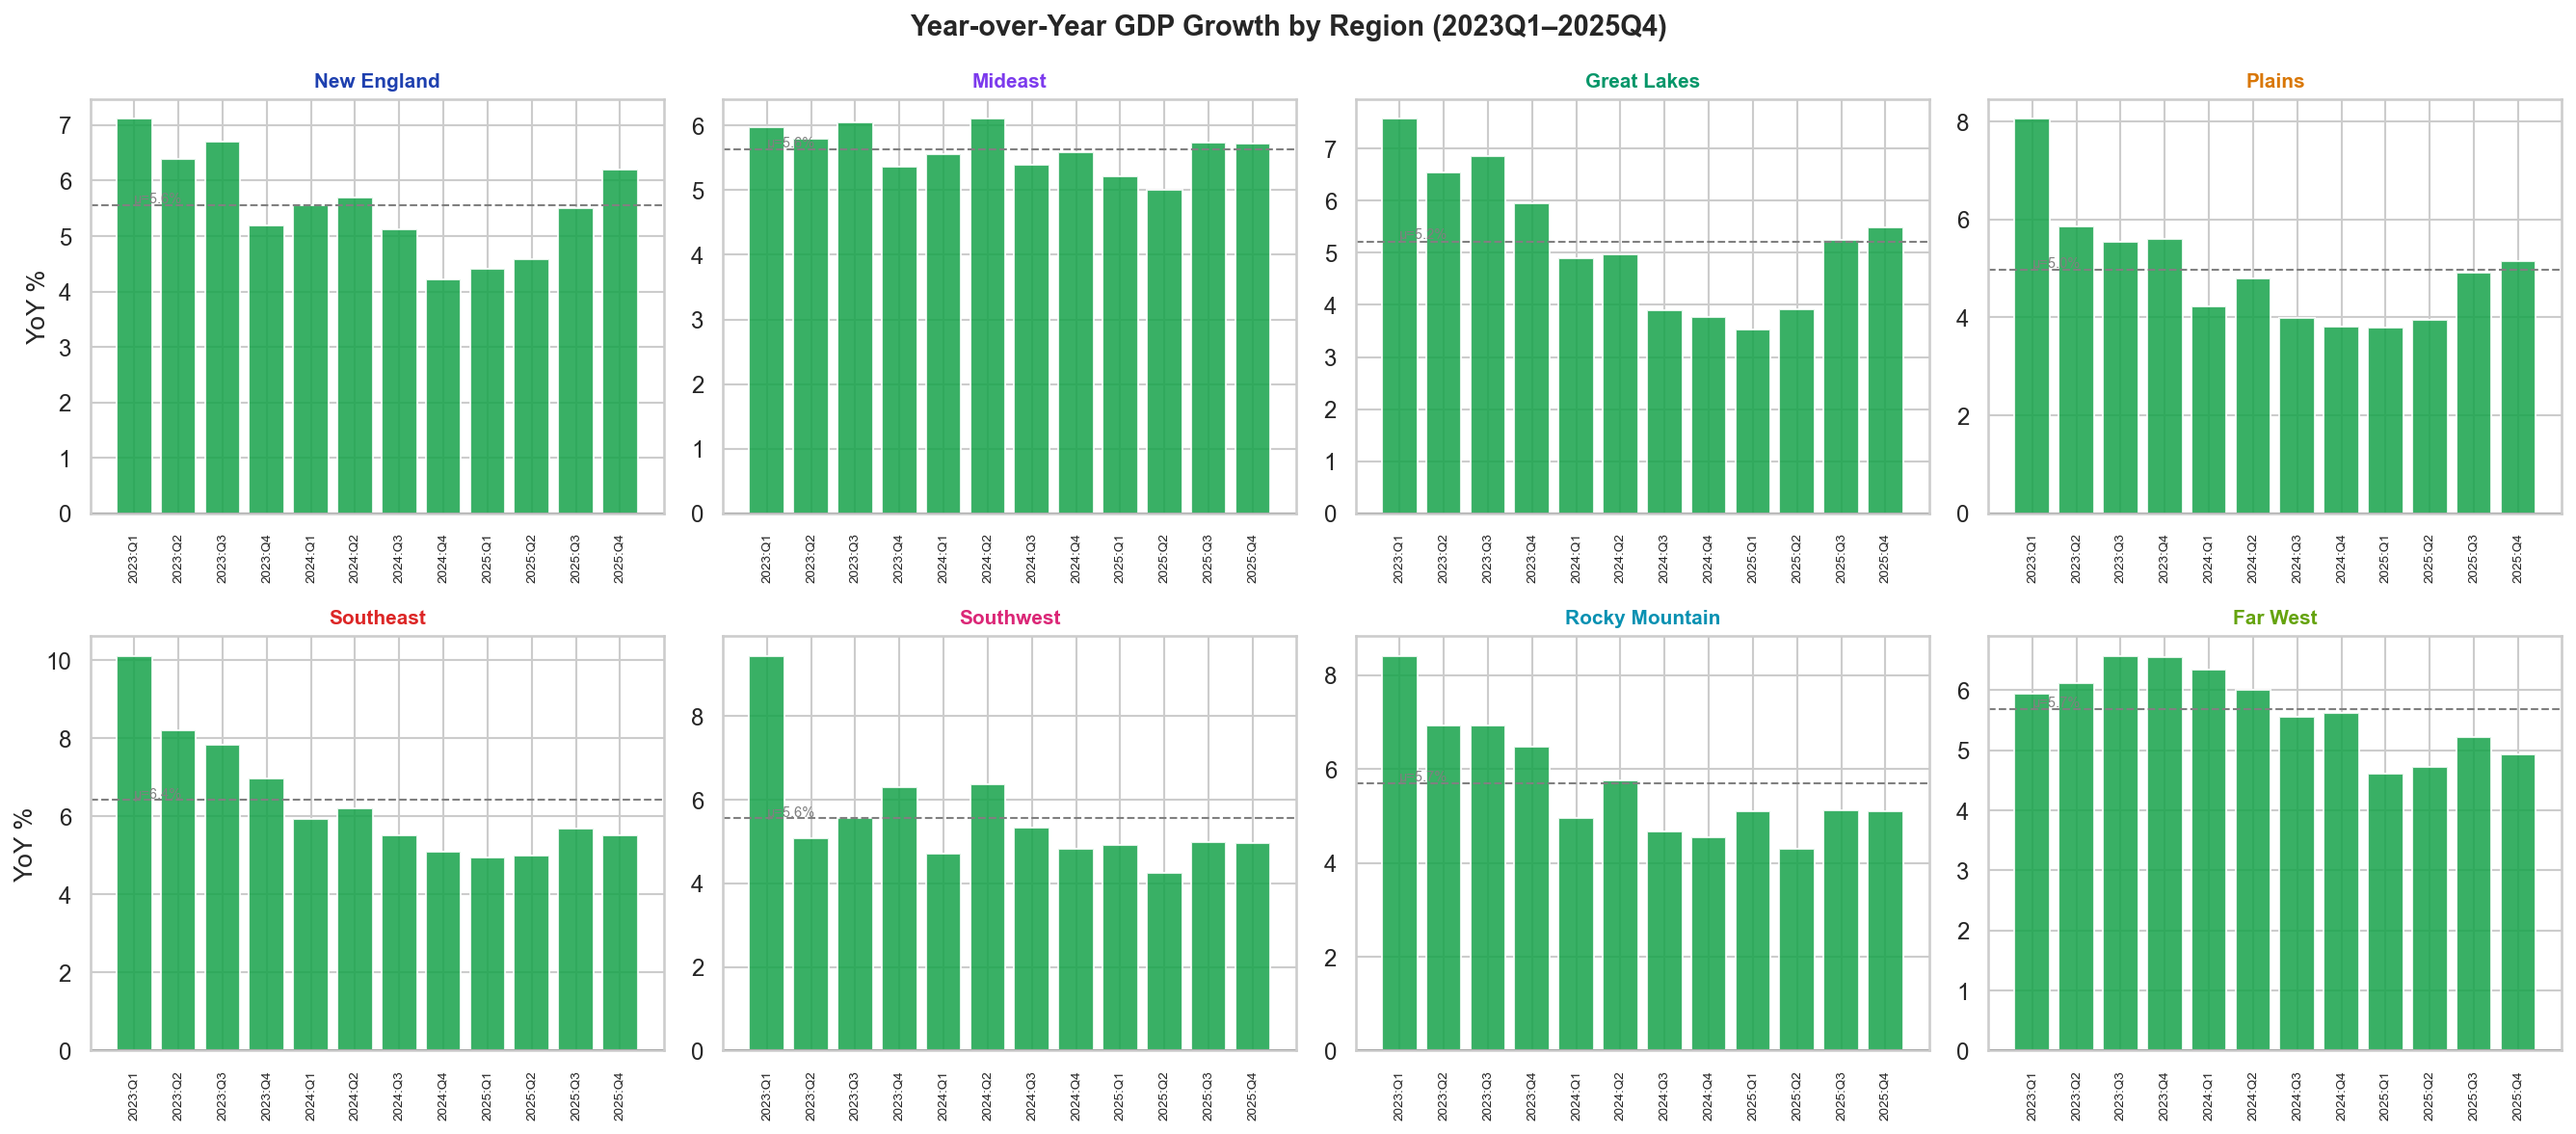

In [17]:
# ── YoY Growth by Region (Small Multiples) ───────────────────────────
yoy_avail = reg_total.dropna(subset=["YoY_Growth"])
fig, axes = plt.subplots(2,4, figsize=(18,8), sharey=False)
axes = axes.flatten()
fig.suptitle("Year-over-Year GDP Growth by Region (2023Q1–2025Q4)",
             fontsize=14, fontweight="bold")
for i, reg in enumerate(REGIONS):
    ax = axes[i]
    rdf = yoy_avail[yoy_avail["Region"]==reg].sort_values("Period")
    clrs = [GREEN if v>=0 else HIGHLIGHT for v in rdf["YoY_Growth"]]
    ax.bar(range(len(rdf)), rdf["YoY_Growth"].values, color=clrs, alpha=0.85)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(reg, fontsize=10, fontweight="bold",
                 color=REGION_COLORS[reg])
    ax.set_xticks(range(len(rdf)))
    ax.set_xticklabels(rdf["Quarter"].tolist(), rotation=90, fontsize=6.5)
    ax.set_ylabel("YoY %" if i%4==0 else "")
    mean_g = rdf["YoY_Growth"].mean()
    ax.axhline(mean_g, color="gray", lw=1, linestyle="--")
    ax.text(0, mean_g+0.05, f"μ={mean_g:.1f}%", fontsize=7, color="gray")
plt.tight_layout()
plt.show()

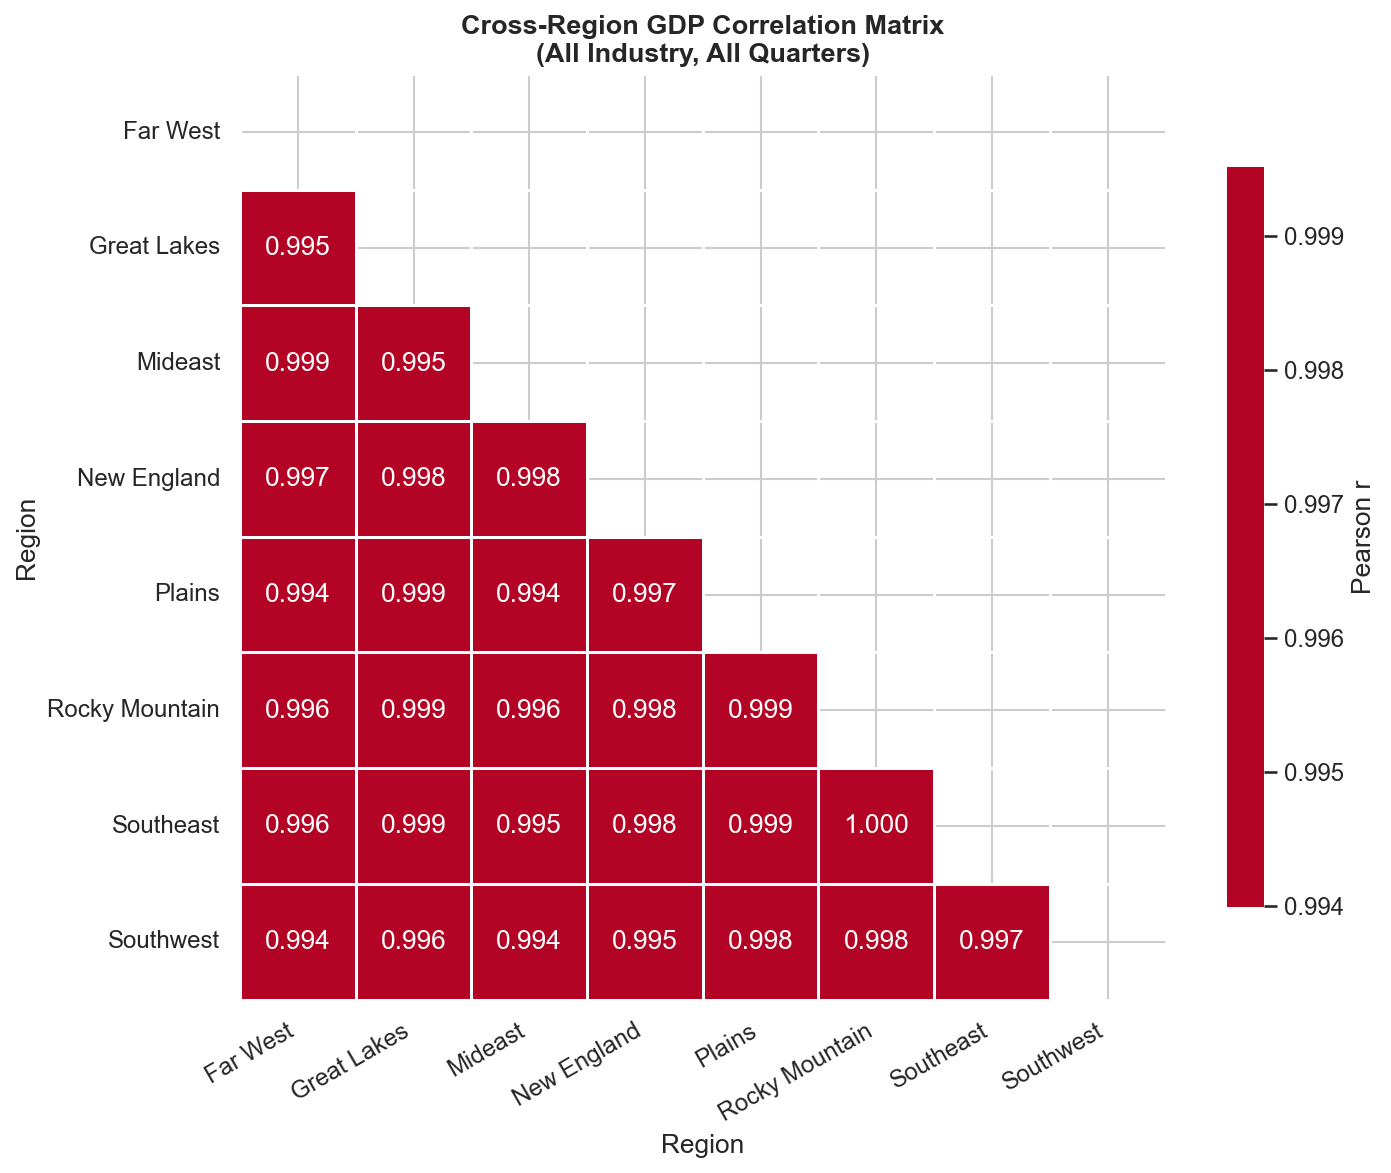

In [18]:
# ──Correlation Matrix: Region GDP ───────────────────────────────────
reg_corr = reg_pivot.T.corr()
fig, ax = plt.subplots(figsize=(10,8))
mask = np.triu(np.ones_like(reg_corr, dtype=bool))
sns.heatmap(reg_corr, ax=ax, mask=mask, cmap="coolwarm", center=0,
            annot=True, fmt=".3f", linewidths=0.5, square=True,
            cbar_kws={"label":"Pearson r", "shrink":0.8})
ax.set_title("Cross-Region GDP Correlation Matrix\n(All Industry, All Quarters)",
             fontsize=13, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

Hypothesis Testing

In [19]:
ht_results = []
 
# ── Test1: Did US GDP grow significantly 2022→2025? ──────────────────────────
gdp_22 = us_gdp[:4]
gdp_25 = us_gdp[12:16]
t1, p1 = stats.ttest_ind(gdp_25, gdp_22)
c1 = "REJECT H₀" if p1/2 < 0.05 else "FAIL TO REJECT"
print(f"\n[T1] Independent t-test — US GDP: 2022 vs 2025")
print(f"  t={t1:.4f}  p(one-tail)={p1/2:.6f}  → {c1}")
ht_results.append({"Test":"t-test: 2022 vs 2025","Stat":t1,"p":p1/2,"Result":c1})


[T1] Independent t-test — US GDP: 2022 vs 2025
  t=10.4853  p(one-tail)=0.000022  → REJECT H₀


In [20]:
# ── Test2: Paired t-test — Q1 vs Q3 across all regions ──────────────────────
q1v = reg_total[reg_total["Qtr"]==1]["GDP_M"].values
q3v = reg_total[reg_total["Qtr"]==3]["GDP_M"].values
n_min = min(len(q1v),len(q3v))
t2, p2 = stats.ttest_rel(q3v[:n_min], q1v[:n_min])
c2 = "REJECT H₀" if p2 < 0.05 else "FAIL TO REJECT"
print(f"\n[T2] Paired t-test — Q1 vs Q3 GDP (all regions)")
print(f"  t={t2:.4f}  p={p2:.6f}  → {c2}")
ht_results.append({"Test":"Paired t-test: Q1 vs Q3","Stat":t2,"p":p2,"Result":c2})


[T2] Paired t-test — Q1 vs Q3 GDP (all regions)
  t=9.6205  p=0.000000  → REJECT H₀


In [21]:
# ── Test3: One-Way ANOVA — GDP level across 8 regions ───────────────────────
region_groups = [reg_total[reg_total["Region"]==r]["GDP_M"].values for r in REGIONS]
f3, p3 = stats.f_oneway(*region_groups)
c3 = "REJECT H₀" if p3 < 0.05 else "FAIL TO REJECT"
print(f"\n[T3] One-Way ANOVA — GDP across 8 regions")
print(f"  F={f3:.4f}  p={p3:.6f}  → {c3}")
ht_results.append({"Test":"ANOVA: GDP by Region","Stat":f3,"p":p3,"Result":c3})


[T3] One-Way ANOVA — GDP across 8 regions
  F=856.5924  p=0.000000  → REJECT H₀


In [22]:
# ── Test4: Post-hoc Tukey HSD ────────────────────────────────────────────────
print(f"\n[T4] Tukey HSD (post-hoc ANOVA):")
tukey_df = reg_total[["GDP_M","Region"]].dropna()
tukey_res = pairwise_tukeyhsd(tukey_df["GDP_M"], tukey_df["Region"], alpha=0.05)
print(tukey_res.summary())


[T4] Tukey HSD (post-hoc ANOVA):
                 Multiple Comparison of Means - Tukey HSD, FWER=0.05                 
    group1         group2        meandiff   p-adj      lower         upper     reject
-------------------------------------------------------------------------------------
      Far West    Great Lakes -1870177.4562    0.0 -2163767.5717 -1576587.3408   True
      Far West        Mideast  -638517.2625    0.0   -932107.378   -344927.147   True
      Far West    New England -4081847.1812    0.0 -4375437.2967 -3788257.0658   True
      Far West         Plains -3767168.2312    0.0 -4060758.3467 -3473578.1158   True
      Far West Rocky Mountain -4438880.9312    0.0 -4732471.0467 -4145290.8158   True
      Far West      Southeast    803998.075    0.0   510407.9595  1097588.1905   True
      Far West      Southwest    -1878167.0    0.0 -2171757.1155 -1584576.8845   True
   Great Lakes        Mideast  1231660.1938    0.0   938070.0783  1525250.3092   True
   Great Lakes    Ne

In [23]:
# ── Test5: Kruskal-Wallis — non-parametric GDP by quarter ───────────────────
qtr_groups = [reg_total[reg_total["Qtr"]==q]["GDP_M"].values for q in [1,2,3,4]]
kw5, pk5 = stats.kruskal(*qtr_groups)
c5 = "REJECT H₀" if pk5 < 0.05 else "FAIL TO REJECT"
print(f"\n[T5] Kruskal-Wallis — GDP by Quarter (Q1/Q2/Q3/Q4)")
print(f"  H={kw5:.4f}  p={pk5:.6f}  → {c5}")
ht_results.append({"Test":"Kruskal-Wallis: by Quarter","Stat":kw5,"p":pk5,"Result":c5})


[T5] Kruskal-Wallis — GDP by Quarter (Q1/Q2/Q3/Q4)
  H=0.2749  p=0.964671  → FAIL TO REJECT


In [24]:
# ── T6: Levene's Test — variance homogeneity across regions ──────────────
lev_stat, lev_p = stats.levene(*region_groups)
c6 = "REJECT H₀ (variances differ)" if lev_p < 0.05 else "FAIL TO REJECT (equal var)"
print(f"\n[T6] Levene's Test — Equal Variance across Regions")
print(f"  W={lev_stat:.4f}  p={lev_p:.6f}  → {c6}")
ht_results.append({"Test":"Levene: Variance by Region","Stat":lev_stat,"p":lev_p,"Result":c6})


[T6] Levene's Test — Equal Variance across Regions
  W=11.1124  p=0.000000  → REJECT H₀ (variances differ)


In [25]:
# ── Test7: Mann-Whitney U — Southeast vs Rocky Mountain ─────────────────────
se  = reg_total[reg_total["Region"]=="Southeast"]["GDP_M"].values
rm  = reg_total[reg_total["Region"]=="Rocky Mountain"]["GDP_M"].values
mw7, pm7 = stats.mannwhitneyu(se, rm, alternative="greater")
c7 = "REJECT H₀" if pm7 < 0.05 else "FAIL TO REJECT"
print(f"\n[T7] Mann-Whitney U — Southeast > Rocky Mountain GDP")
print(f"  U={mw7:.1f}  p={pm7:.6f}  → {c7}")
ht_results.append({"Test":"Mann-Whitney: SE > RM","Stat":mw7,"p":pm7,"Result":c7})


[T7] Mann-Whitney U — Southeast > Rocky Mountain GDP
  U=256.0  p=0.000001  → REJECT H₀


In [26]:
# ── Test8: Chi-Square — Growth category vs Region ────────────────────────────
reg2 = reg_total.dropna(subset=["QoQ_Growth"]).copy()
reg2["Growth_Cat"] = pd.qcut(reg2["QoQ_Growth"], q=4,
                              labels=["Low","Med-Low","Med-High","High"])
ct8 = pd.crosstab(reg2["Region"], reg2["Growth_Cat"])
chi8, pchi8, dof8, _ = stats.chi2_contingency(ct8)
c8 = "REJECT H₀" if pchi8 < 0.05 else "FAIL TO REJECT"
print(f"\n[T8] Chi-Square — Growth Category × Region")
print(f"  χ²={chi8:.4f}  df={dof8}  p={pchi8:.6f}  → {c8}")
ht_results.append({"Test":"Chi-Sq: Growth×Region","Stat":chi8,"p":pchi8,"Result":c8})


[T8] Chi-Square — Growth Category × Region
  χ²=20.2667  df=21  p=0.504431  → FAIL TO REJECT


In [27]:
# ── Test9: ADF Stationarity (US GDP) ─────────────────────────────────────────
adf9 = adfuller(us_gdp, autolag="AIC")
print(f"\n[T9] ADF Stationarity — US GDP")
print(f"  ADF={adf9[0]:.4f}  p={adf9[1]:.4f}")
print(f"  Critical values: {adf9[4]}")
print(f"  → {'NON-STATIONARY (unit root)' if adf9[1]>0.05 else 'STATIONARY'}")


[T9] ADF Stationarity — US GDP
  ADF=-0.9766  p=0.7617
  Critical values: {'1%': -4.473135048010974, '5%': -3.28988060356653, '10%': -2.7723823456790124}
  → NON-STATIONARY (unit root)


In [28]:
# ── Test10: Welch ANOVA — Far West vs others ─────────────────────────────────
fw  = reg_total[reg_total["Region"]=="Far West"]["GDP_M"].values
oth = reg_total[reg_total["Region"]!="Far West"]["GDP_M"].values
t10, p10 = stats.ttest_ind(fw, oth, equal_var=False)
c10 = "REJECT H₀" if p10 < 0.05 else "FAIL TO REJECT"
print(f"\n[T10] Welch's t-test — Far West vs All Other Regions")
print(f"  t={t10:.4f}  p={p10:.6f}  → {c10}")
ht_results.append({"Test":"Welch: Far West vs Rest","Stat":t10,"p":p10,"Result":c10})


[T10] Welch's t-test — Far West vs All Other Regions
  t=11.6339  p=0.000000  → REJECT H₀


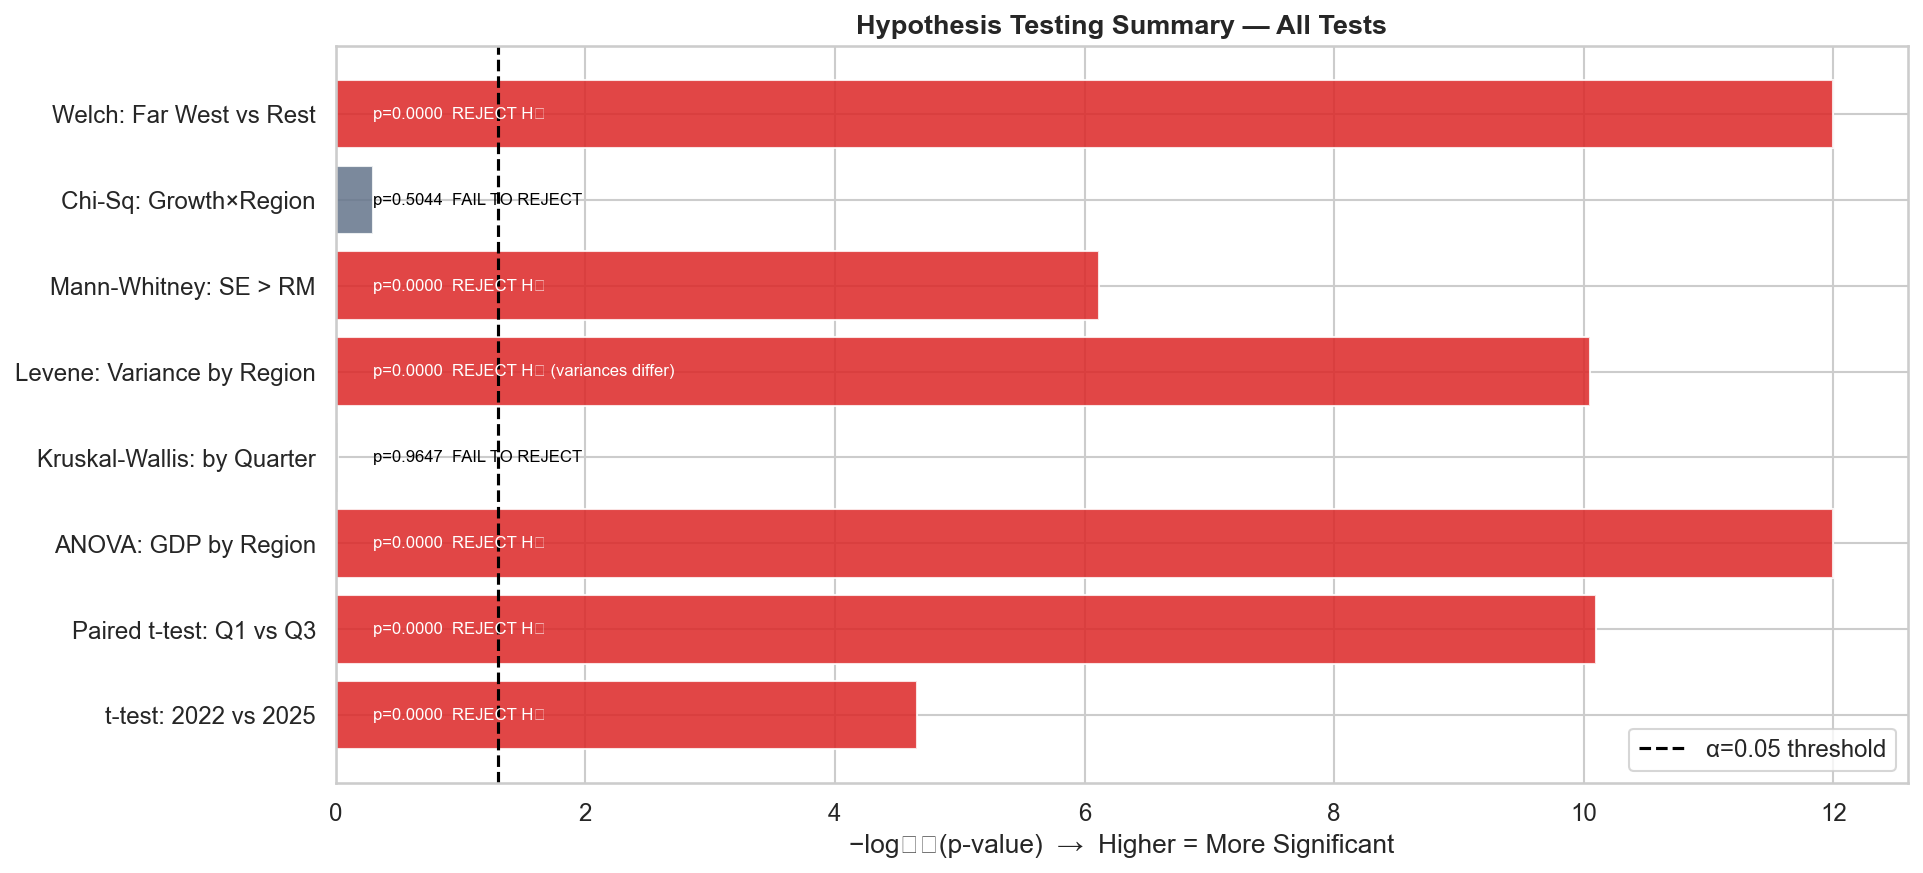

In [29]:
df_ht = pd.DataFrame(ht_results)
fig, ax = plt.subplots(figsize=(13,6))
clrs_ht = [HIGHLIGHT if p<0.05 else NEUTRAL for p in df_ht["p"]]
ax.barh(df_ht["Test"], -np.log10(df_ht["p"].clip(lower=1e-12)),
        color=clrs_ht, alpha=0.85)
ax.axvline(-np.log10(0.05), color="black", lw=1.5, linestyle="--",
           label="α=0.05 threshold")
ax.set_xlabel("−log₁₀(p-value)  →  Higher = More Significant")
ax.set_title("Hypothesis Testing Summary — All Tests",
             fontsize=13, fontweight="bold")
ax.legend()
for i,(_, row) in enumerate(df_ht.iterrows()):
    ax.text(0.3, i, f"p={row['p']:.4f}  {row['Result']}",
            va="center", fontsize=8, color="white" if row["p"]<0.05 else "black")
plt.tight_layout()
plt.show()